In [1]:
import sys
import os
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

from collections import defaultdict, deque # deque is nodig voor histwrapper
from gymnasium import spaces, Wrapper # Wrapper is de basisklasse voor custom wrappers
import matplotlib.pyplot as plt
import gymnasium as gym


sys.path.append(os.path.expanduser("~/src/swingup/q_learning"))
from UnbalancedDiskDiscrete_latest_oldy import UnbalancedDisk

In [2]:
class UnbalancedDiskResetWrapper(gym.Wrapper):
    """
    Wrapper om de reset methode van de omgeving te normaliseren
    voor compatibiliteit met verschillende Gymnasium versies.
    """
    def __init__(self, env): super().__init__(env)
    def reset(self, *, seed=None, options=None):
        try: obs, info = self.env.reset(seed=seed)
        except TypeError: obs, info = self.env.reset();
        return obs, info

class Discretize_obs(gym.Wrapper):
    """
    Wrapper om de continue observatieruimte te discretiseren naar MultiDiscrete.
    Dit is essentieel voor traditionele Q-learning, die discrete staten vereist.
    """
    def __init__(self, env, nvec):
        super(Discretize_obs, self).__init__(env)

        original_obs_space = env.observation_space
        
        # --- Initialisatie van self.nvec_array en de nieuwe observation_space ---
        if isinstance(original_obs_space, spaces.Box):
            # Als de originele ruimte een Box (continu) is, dan gebruiken we de shape.
            original_obs_shape = original_obs_space.shape
            self.olow = original_obs_space.low
            self.ohigh = original_obs_space.high
        elif isinstance(original_obs_space, spaces.MultiDiscrete):
            # Als de originele ruimte al MultiDiscrete is, dan is de 'shape' de lengte van nvec.
            original_obs_shape = original_obs_space.nvec.shape
            self.olow = np.zeros_like(original_obs_space.nvec, dtype=np.float32)
            self.ohigh = (original_obs_space.nvec - 1).astype(np.float32)
        else:
            raise TypeError(f"Onondersteund observatieruimte type van onderliggende omgeving: {type(original_obs_space)}. Verwacht Box of MultiDiscrete.")

        if isinstance(nvec, int):
            # Als nvec een enkel getal is, vul dan een NumPy array met die waarde,
            # met de juiste vorm van de observatie.
            self.nvec_array = np.full(original_obs_shape, nvec, dtype=int)
        else:
            # Als nvec al een array/lijst is, zorg dan dat het de juiste vorm heeft.
            self.nvec_array = np.array(nvec, dtype=int)
            if self.nvec_array.shape != original_obs_shape:
                raise ValueError(f"De meegeleverde nvec shape {self.nvec_array.shape} komt niet overeen "
                                 f"met de observatieruimte shape {original_obs_shape}")
        
        self.observation_space = gym.spaces.MultiDiscrete(self.nvec_array.flatten())
        self.range_obs = self.ohigh - self.olow
        self.range_obs[self.range_obs == 0] = 1.0 # Vervang nullen door 1.0

    def discretize(self, observation):
        """
        Converteert een continue observatie naar een discrete tuple.
        """
        observation = np.clip(observation, self.olow, self.ohigh)
        discrete_obs_float = ((observation - self.olow) / self.range_obs * self.nvec_array)
        return tuple(np.clip(discrete_obs_float, 0, self.nvec_array - 1).astype(int).flatten())
        
    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)
        return self.discretize(observation), reward, terminated, truncated, info

    def reset(self):
        obs, info = self.env.reset()
        obs_dis = self.discretize(obs)
        return obs_dis, info


def roll_mean(ar,start=2000,N=50): #smoothing if needed
    """
    Berekent een exponentieel voortschrijdend gemiddelde.
    `start` is de initiële waarde voor het gemiddelde.
    `N` bepaalt de gladheid (hoe groter N, hoe gladder).
    """
    s = 1-1/N
    k = start
    out = np.zeros(ar.shape)
    for i,a in enumerate(ar):
        k = s*k + (1-s)*a
    return out

def argmax(a):
    """
    Retourneert een willekeurige index van de maximale waarde in een array.
    Dit voorkomt een bias bij meerdere gelijke maximale waarden (tie-breaking).
    """
    a = np.array(a)
    return np.random.choice(np.arange(len(a),dtype=int)[a==np.max(a)])




In [3]:
def Qlearn(env, nsteps=5000, nvec_angle = 360 , nvec_rps = 30 ,callbackfeq=5000, alpha=0.05, gamma=0.98, checkpoint_name='best_Qmat.pkl', callback=None):
    import pickle
    Qmat = defaultdict(float)
    env_time = env

    while not isinstance(env_time,gym.wrappers.TimeLimit):
        if hasattr(env_time, 'env'):
            env_time = env_time.env
        else:
            print("Waarschuwing: Kan geen gym.wrappers.TimeLimit vinden in de omgeving. _elapsed_steps is mogelijk niet beschikbaar.")
            break
            
    ep_lengths = []
    ep_lengths_steps = []
    ep_rewards = []
    obs, info = env.reset()
    current_episode_reward = 0.0
    best_avg_reward = -float('inf')
    best_Qmat_to_save = None

    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_loaded_at_start = pickle.load(f)
                Qmat.update(Qmat_loaded_at_start)
            print(f"Succesvol initiële Qmat geladen van {checkpoint_name}. Training wordt voortgezet.")
        except Exception as e:
            print(f"Waarschuwing: Kon initiële Qmat niet laden van {checkpoint_name}: {e}. Starten met een lege Qmat.")
    else:
        print(f"Geen initieel checkpoint gevonden op {checkpoint_name}. Starten met een lege Qmat.")
            
    for z in range(nsteps):
        # eps = 0.6 - 0.55 * z / (nsteps - 1)

        # eps = max(0.05,
        #         1 - 0.95 * z / (nvec_angle * nvec_rps * 3 - 1),
        #         0.3 - 0.25 * z * 1.4 / (nsteps - 1))

        # eps = max(
        #     0.05,  # Minimum threshold for eps
        #     1 - 0.99 * z / (nvec_angle * nvec_rps * 2.5 - 1),         # First decay function
        #     0.3 - 0.15 * z * 1.4 / (nsteps - 1) ,                     # Second decay function
        #     0.4 - 0.15 * z *3/ (nsteps - 1)
        # )
        eps = max(
            0.02,  # Minimum threshold for eps
            # 
            # exponentiële decay functie die snel begint en langzaam afneemt, met een asymptoot bij 0.05
            0.7 * np.exp(-5 * z / nsteps) + 0.02
        )

        if np.random.uniform()<eps:
            action = env.action_space.sample()
        else:
            action = argmax([Qmat[(obs, i)] for i in range(env.action_space.n)])
            
        obs_new, reward, terminated, truncated, info = env.step(action)
        current_episode_reward += reward

        if callback and z % callbackfeq == 0:
            callback(Qmat, z, env)

        if terminated or truncated:
            A = reward - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha * A
            
            print_status_message = ""
            if terminated:
                print_status_message = f"{env_time._elapsed_steps}, stap {z+1}. Totale Beloning: {current_episode_reward:.2f}"
            elif truncated:
                print_status_message = f"{env_time._elapsed_steps}, stap {z+1}. Totale Beloning: {current_episode_reward:.2f}"
            
            
            ep_lengths.append(env_time._elapsed_steps)
            ep_lengths_steps.append(z)
            ep_rewards.append(current_episode_reward)
            obs, info = env.reset()
            if current_episode_reward > best_avg_reward:
                best_avg_reward = current_episode_reward
                best_Qmat_to_save = Qmat.copy()
                
                try:
                    with open(checkpoint_name, 'wb') as f:
                        pickle.dump(best_Qmat_to_save, f)
                    print(f"################################# \n NIEUWE BESTE GEMIDDELDE BELONING: {current_episode_reward}, Qmat opgeslagen naar {checkpoint_name}... \n#################################")
                except Exception as e:
                    print(f"Fout bij opslaan Qmat: {e}")

                    
            current_episode_reward = 0.0
            print(print_status_message)

        else:
            A = reward + gamma * max(Qmat[(obs_new, action_next)] for action_next in range(env.action_space.n)) - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha * A
            obs = obs_new

    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_final = pickle.load(f)
            print(f"Laden van de uiteindelijke beste Qmat (gemiddelde beloning: {best_avg_reward:.2f}) van {checkpoint_name}")
            return Qmat_final, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
        except Exception as e:
            print(f"Fout bij laden van de uiteindelijke beste Qmat van {checkpoint_name}: {e}. Huidige Qmat wordt geretourneerd.")
    elif best_Qmat_to_save is not None:
        print("Geen checkpointbestand gevonden, maar best_Qmat_to_save was ingesteld. Deze wordt geretourneerd.")
        return best_Qmat_to_save, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
    else:
        print("Geen beste Qmat is opgeslagen tijdens training (mogelijk niet genoeg episodes of geen verbetering). Huidige Qmat wordt geretourneerd.")

    return Qmat, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)


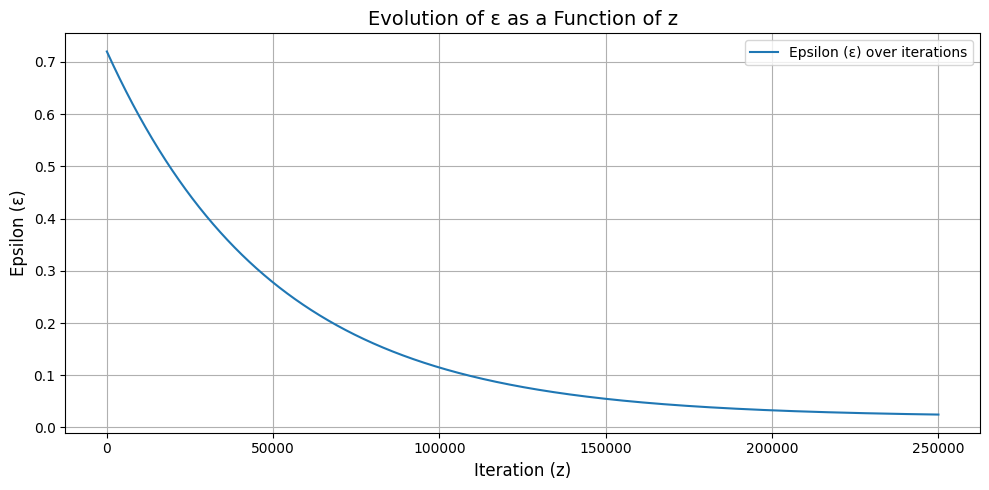

In [4]:
import matplotlib.pyplot as plt

# Define parameters
n_steps = 250_000                # Total number of steps (samples)
n_vec_angle = 360                  # Number of angular divisions
n_vec_rps = 30                     # Rotations per second

# Create the z-axis values
z_values = range(n_steps)

# Compute epsilon values with piecewise decay logic
# eps_values = [
#     max(
#         0.05,  # Minimum threshold for eps
#         1 - 0.99 * z / (n_vec_angle * n_vec_rps * 2.5 - 1),         # First decay function
#         0.3 - 0.15 * z * 1.4 / (n_steps - 1) ,                     # Second decay function
#         0.4 - 0.15 * z *3/ (n_steps - 1)
#     )
#     for z in z_values
# ]


eps_values = [
    max(
        0.02,  # Minimum threshold for eps
        # exponentiële decay functie die snel begint en langzaam afneemt, met een asymptoot bij 0.05
        # 0.3 * np.exp(-5 * z / n_steps) + 0.05
        0.7 * np.exp(-5 * z / (n_steps)) + 0.02
    )
    for z in z_values
]


# eps_values = [
#     max(0.05,
#                 1 - 0.95 * z / (n_vec_angle * n_vec_rps * 3 - 1),
#                 0.3 - 0.25 * z * 1.4 / (n_vec_rps - 1))
#     for z in z_values
# ]

# Plot the evolution of epsilon over z
plt.figure(figsize=(10, 5))
plt.plot(z_values, eps_values, label="Epsilon (ε) over iterations")
plt.xlabel("Iteration (z)", fontsize=12)
plt.ylabel("Epsilon (ε)", fontsize=12)
plt.title("Evolution of ε as a Function of z", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [5]:
# --- Hoofddeel van het Script: Training en Evaluatie ---

checkpoint_filename = 'Q_learning_2_neww_reward_v13.pkl' # De bestandsnaam voor jouw opgeslagen Q-tabel

# --- Trainingsfase ---
print("\n--- START TRAINING ---")
nvec_angle = 360
nvec_rps = 50
max_episode_steps_train = 300
Qmats = {}
for nvec in [20]:
    env_train = UnbalancedDisk(dt=0.025, umax=3., render_mode=None)
    env_train = UnbalancedDiskResetWrapper(env_train)
    env_train = gym.wrappers.TimeLimit(env_train, max_episode_steps=max_episode_steps_train)
    env_train = Discretize_obs(env_train, nvec=[nvec_angle,nvec_rps])

    print(f'nvec={nvec}')
    Qmat_trained, ep_lengths_steps, ep_lengths, ep_rewards = Qlearn(
        env_train,
        nsteps=350_000, # Aantal trainingsstappen
        nvec_angle = nvec_angle,
        nvec_rps = nvec_rps,
        callbackfeq=5000, # Frequentie voor evaluatie en potentieel opslaan
        checkpoint_name=checkpoint_filename # De gedefinieerde bestandsnaam
    )
    Qmats[nvec] = Qmat_trained
    env_train.close()

if os.path.exists(checkpoint_filename):
    print(f"\nCheck: Checkpoint file '{checkpoint_filename}' found on disk.")
    try:
        import pickle
        with open(checkpoint_filename, 'rb') as f:
            loaded_Qmat_final_check = pickle.load(f)
        print(f"Successfully loaded Qmat from '{checkpoint_filename}' for final check. Size: {len(loaded_Qmat_final_check)} entries.")
    except Exception as e:
        print(f"Error loading saved Qmat for final check: {e}")
else:
    print(f"\nCheck: Checkpoint file '{checkpoint_filename}' NOT found on disk.")





--- START TRAINING ---
nvec=20
Succesvol initiële Qmat geladen van Q_learning_2_neww_reward_v13.pkl. Training wordt voortgezet.
################################# 
 NIEUWE BESTE GEMIDDELDE BELONING: -66.18603972675909, Qmat opgeslagen naar Q_learning_2_neww_reward_v13.pkl... 
#################################
300, stap 300. Totale Beloning: -66.19
################################# 
 NIEUWE BESTE GEMIDDELDE BELONING: -32.9973693529507, Qmat opgeslagen naar Q_learning_2_neww_reward_v13.pkl... 
#################################
300, stap 600. Totale Beloning: -33.00
300, stap 900. Totale Beloning: -60.89
300, stap 1200. Totale Beloning: -52.17
300, stap 1500. Totale Beloning: -56.83
300, stap 1800. Totale Beloning: -71.34
300, stap 2100. Totale Beloning: -47.89
300, stap 2400. Totale Beloning: -53.65
300, stap 2700. Totale Beloning: -55.52
300, stap 3000. Totale Beloning: -53.35
300, stap 3300. Totale Beloning: -71.20
################################# 
 NIEUWE BESTE GEMIDDELDE BELONING: -

Laatste 10 episode beloningen: [217.23842843  -2.21347834 -59.70204125  -0.68464776  -1.85044804
 399.12245115  -5.2367819   -2.07091059 131.04559231   0.5254652 ]


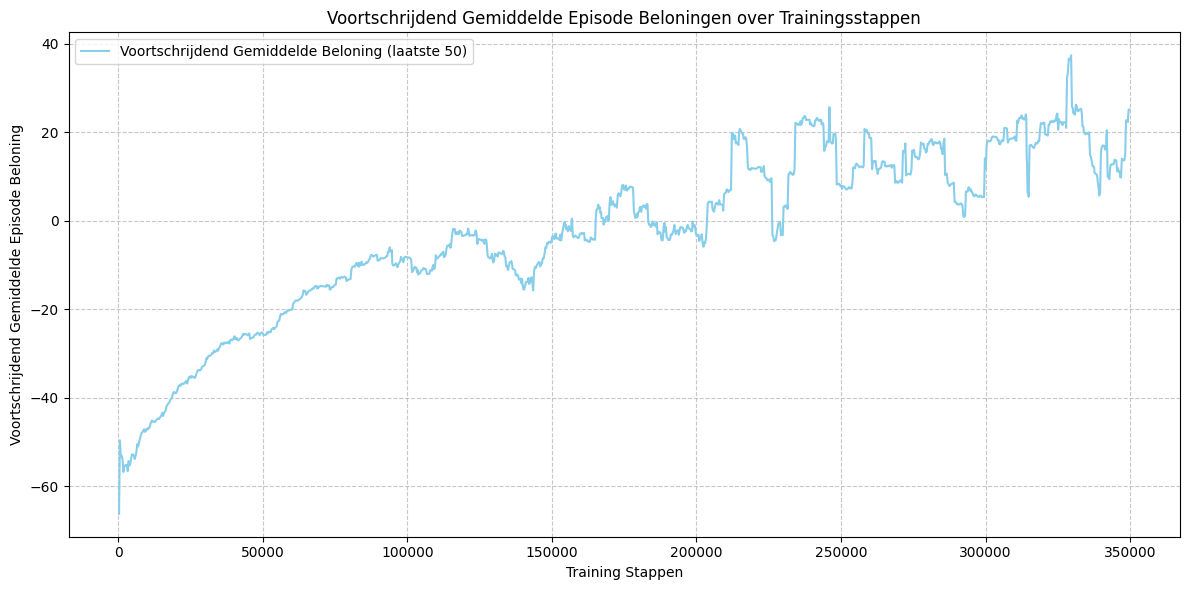

In [6]:
from matplotlib import pyplot as plt
import numpy as np
print(f"Laatste 10 episode beloningen: {ep_rewards[-10:]}")
N_ROLLING_MEAN = 50 # Je kunt dit aanpassen naar behoefte
rolled_rewards = []
for i in range(len(ep_rewards)):
    start_index = max(0, i - N_ROLLING_MEAN + 1)
    rolled_rewards.append(np.mean(ep_rewards[start_index:i+1]))

plt.figure(figsize=(12, 6)) # Optioneel: Maak de plot wat groter
plt.plot(ep_lengths_steps, rolled_rewards, label=f'Voortschrijdend Gemiddelde Beloning (laatste {N_ROLLING_MEAN})', color='skyblue')
plt.legend()
plt.xlabel("Training Stappen")
plt.ylabel("Voortschrijdend Gemiddelde Episode Beloning")
plt.title("Voortschrijdend Gemiddelde Episode Beloningen over Trainingsstappen")
plt.grid(True, linestyle='--', alpha=0.7) # Voeg een subtiel raster toe
plt.tight_layout() # Zorgt ervoor dat alle elementen goed passen
plt.show()

In [ ]:

import gymnasium as gym
from gymnasium import spaces
import numpy as np
from scipy.integrate import solve_ivp
from os import path

class UnbalancedDisk(gym.Env):
    '''
    UnbalancedDisk
    th =            
                  +-pi
                    |
           pi/2   ----- -pi/2
                    |
                    0  = starting location
    '''
    def __init__(self, umax=3., dt = 0.025, render_mode='human'):
        ############# start do not edit  ################
        self.omega0 = 11.339846957335382
        self.delta_th = 0
        self.gamma = 1.3328339309394384
        self.Ku = 28.136158407237073
        self.Fc = 6.062729509386865
        self.coulomb_omega = 0.001

        # self.g = 9.80155078791343
        # self.J = 0.000244210523960356
        # self.Km = 10.5081817407479
        # self.I = 0.0410772235841364
        # self.M = 0.0761844495320390
        # self.tau = 0.397973147009910
        ############# end do not edit ###################

        self.umax = umax
        self.dt = dt #time step
        self.num_actions = 7
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(self.num_actions)
        self.discrete_action_map  = [-3, -1.8,  -0.5 ,  0,  0.5, 1.8,  3] #1
        # self.discrete_action_map  = [-3, -1.2 ,  0, 1.2,  3] #1
        # self.discrete_action_map  = [-3,  -2, -1,  -0.5 , -0.2, 0,  0.2, 0.5, 1, 2, 3] #2
        # self.discrete_action_map  = [-3,  -1.7, -0.7,  -0.2, 0,  0.2, 0.7, 1.7, 3] #3
        low = [-2*np.pi,-5] 
        high = [2*np.pi,5]
        self.observation_space = spaces.Box(low=np.array(low,dtype=np.float32),high=np.array(high,dtype=np.float32),shape=(2,))



        # AANGEPAST: self.err functie accepteert nu 'current_th' en 'target_th'
        self.err = lambda current_th, target_th: abs(((current_th - target_th + np.pi) % (2 * np.pi)) - np.pi)
        # self.err = lambda self: abs(((self.th - np.pi + np.pi) % (2 * np.pi)) - np.pi)
        # Helper function for 2D Gaussian
        def gaussian_2d(val_x, val_y, mu_x, mu_y, sigma_x, sigma_y, rho, scale):
            mu = np.array([mu_x, mu_y])
            cov = np.array([[sigma_x**2, rho * sigma_x * sigma_y],
                            [rho * sigma_x * sigma_y, sigma_y**2]])
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)
            diff = np.array([val_x - mu[0], val_y - mu[1]])
            exponent = -0.5 * np.dot(diff, np.dot(inv_cov, diff.T))
            return scale * (1.0 / (2 * np.pi * np.sqrt(det_cov))) * np.exp(exponent)

        # Nieuwe klasse attributen voor de parameters van calculate_z
        self.A_VALUE = 3.25
        self.B_VALUE = 0.7
        self.J_VALUE = 2.0 # Gebruik 2.0 zoals in de reward_function_for_plot

        def _calculate_z_internal():
            """
            Berekent de waarde van z op basis van de gegeven wiskundige formule,
            gebruikmakend van de huidige th, omega en constante waarden van de klasse.
            Ongepaste waarden worden op 0 gezet.
            """
            # De hoofdberekening voor z
            term1 = np.sin(self.omega - np.sin(self.th) * self.A_VALUE + 0.5 * np.pi)
            term2 = (self.J_VALUE + np.sin(self.th - 0.5 * np.pi) * 2)
            z = term1 * self.B_VALUE * term2

            # Toepassen van de voorwaarden
            # {sin(x) * a - pi <= y <= sin((x)) * a + pi}
            condition_y_lower = np.sin(self.th) * self.A_VALUE - np.pi
            condition_y_upper = np.sin(self.th) * self.A_VALUE + np.pi
            
            # {-j + 2 <= z}
            condition_z_lower = -self.J_VALUE + 2

            # Maak een masker voor de punten die niet aan de voorwaarden voldoen
            # Als een punt niet aan de voorwaarden voldoet, wordt de waarde ervan 0
            mask = (self.omega >= condition_y_lower) & \
                   (self.omega <= condition_y_upper) & \
                   (z >= condition_z_lower)
            
            # Geef 0 terug voor de punten die niet aan de voorwaarden voldoen
            return np.where(mask, z, 0)
        


        # Wijs de geneste functie toe aan een self variabele zodat reward_fun deze kan aanroepen.
        self.calculate_z_component = _calculate_z_internal



        # DE NIEUWE REWARD FUNCTIE
        self.reward_fun = lambda self_instance: (
            # Hoofdbeloning: Piek op PI (bovenkant) en 0 hoeksnelheid



            +gaussian_2d(self_instance.err(self_instance.th, np.pi), self_instance.omega,  0, 0, 1, 1, 0.0, 2)
            # Straf voor zijn aan de onderkant (rond 0 rad), ongeacht th_ref
            - gaussian_2d(self_instance.err(self_instance.th, 0), self_instance.omega,  0, 0, 3, 3, 0.0, 40)
            + gaussian_2d(self_instance.err(self_instance.th, np.pi), self_instance.omega, 0, 0, 0.15, 0.15, 0.0, 0.05)
            + gaussian_2d(self_instance.err(self_instance.th, np.pi), self_instance.omega, 0, 0, 0.07, 0.07, 0.0, 0.15)


            # Control input penalty
            - 0.001 * self_instance.u**2
            
            # TOEVOEGING van de getransformeerde Z_VALUES
            # Aangepaste aanroep: self_instance.calculate_z_component() in plaats van self_instance.err.calculate_z_component()
            + self_instance.calculate_z_component()
        )

        self.render_mode = render_mode
        self.viewer = None
        self.u = 0 #for visual
        self.prev_u = 0
        self.prev_th = 0
        self.stuck = 0
        self.err_upright = 0
        self.up = False
        self.balancing_ticker = 0 
        self.punishment_over_time = 0
        self.bonus_region = 0
        self.set_th = None
        self.set_omega = None
        self.step_t = 0
        self.time_to_become_stable = 0
        self.th_ref = 0
        self.th_set = 0
        self.reset()

    def termination(self, reward):
        ## termination function for if the system has fallen
        if abs(self.th) > 2 * np.pi:
            # self.up = True
            done = True
            reward -= 50
            # print(f'system is up: {self.up}')

        # if self.up == True and self.err > 1.6:
        #     # reward -= 100
        #     self.balancing_reward = 0
        #     done = False
        #     # print("terminating due to fall!!!")
        else:
            done = False

        return done, reward

    def step(self, action):
        self.u = self.discrete_action_map[action]

        ##### Start Do not edit ######
        self.u = np.clip(self.u,-self.umax,self.umax)
        def f(t,y):
            th, omega = y
            dthdt = omega
            friction = self.gamma*omega + self.Fc*np.tanh(omega/self.coulomb_omega)
            domegadt = -self.omega0**2*np.sin(th+self.delta_th) - friction + self.Ku*self.u
            return np.array([dthdt, domegadt])
        sol = solve_ivp(f,[0,self.dt],[self.th,self.omega]) #integration
        self.th, self.omega = sol.y[:,-1]
        ##### End do not edit   #####

        # first let the system stabilize, then more the setpoint +- 15 deg.
        if self.time_to_become_stable >= 100:
            t = self.dt * self.step_t
            self.th_ref = np.deg2rad(self.th_set) * np.sin(2 * np.pi * 0.2 * t) # move set-point at 0.2 Hz +- 15 deg
            self.step_t += 1
        else:
            self.th_ref = 0
        # self.th_ref = 0
        self.time_to_become_stable += 1
        #####################################################################

        # t = self.dt * self.step_t
        # self.th_ref = np.deg2rad(15) * np.sin(2 * np.pi * 0.2 * t) # move set-point at 0.2 Hz +- 15 deg
        # self.step_t += 1

        reward = self.reward_fun(self)

        reward += self.bonus_region
        done, reward = self.termination(reward)

        return self.get_obs(), reward, done, False, {}
         
    def reset(self,seed=None):
        super().reset(seed=seed)
        self.th = self.set_th if self.set_th is not None else np.random.uniform(-np.pi/4, np.pi/4)
        self.omega = self.set_omega if self.set_omega is not None else np.random.uniform(-1.0, 1.0)
        self.u = 0

        self.step_t = 0
        self.balancing_ticker = 0
        self.time_to_become_stable = 0
        self.bonus_region = 0
        return self.get_obs(), {}

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0,scale=0.001) #do not edit
        self.omega_noise = self.omega + np.random.normal(loc=0,scale=0.001) #do not edit
        return np.array([self.th_noise, self.omega_noise])

    def render(self):
        import pygame
        from pygame import gfxdraw
        
        screen_width = 500
        screen_height = 500

        th = self.th
        omega = self.omega #x = self.state

        if self.viewer is None:
            pygame.init()
            pygame.display.init()
            self.viewer = pygame.display.set_mode((screen_width, screen_height))

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))
        
        gfxdraw.filled_circle( #central blue disk
            self.surf,
            screen_width//2,
            screen_height//2,
            int(screen_width/2*0.65*1.3),
            (32,60,92),
        )
        gfxdraw.filled_circle( #small midle disk
            self.surf,
            screen_width//2,
            screen_height//2,
            int(screen_width/2*0.06*1.3),
            (132,132,126),
        )
        
        from math import cos, sin
        r = screen_width//2*0.40*1.3
        gfxdraw.filled_circle( #disk
            self.surf,
            int(screen_width//2-sin(th)*r), #is direction correct?
            int(screen_height//2-cos(th)*r),
            int(screen_width/2*0.22*1.3),
            (155,140,108),
        )
        gfxdraw.filled_circle( #small nut
            self.surf,
            int(screen_width//2-sin(th)*r), #is direction correct?
            int(screen_height//2-cos(th)*r),
            int(screen_width/2*0.22/8*1.3),
            (71,63,48),
        )
        
        fname = path.join(path.dirname(__file__), "clockwise.png")
        self.arrow = pygame.image.load(fname)
        if self.u:
            if isinstance(self.u, (np.ndarray,list)):
                if self.u.ndim==1:
                    u = self.u[0]
                elif self.u.ndim==0:
                    u = self.u
                else:
                    raise ValueError(f'u={u} is not the correct shape')
            else:
                u = self.u
            arrow_size = abs(float(u)/self.umax*screen_height)*0.25
            Z = (arrow_size, arrow_size)
            arrow_rot = pygame.transform.scale(self.arrow,Z)
            if self.u<0:
                arrow_rot = pygame.transform.flip(arrow_rot, True, False)
                
        self.surf = pygame.transform.flip(self.surf, False, True)
        self.viewer.blit(self.surf, (0, 0))
        if self.u:
            self.viewer.blit(arrow_rot, (screen_width//2-arrow_size//2, screen_height//2-arrow_size//2))
        if self.render_mode == "human":
            pygame.event.pump()
            pygame.display.flip()

        return True

    def close(self):
        if self.viewer is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False
            self.viewer = None


class UnbalancedDisk_sincos(UnbalancedDisk):
    """docstring for UnbalancedDisk_sincos"""
    def __init__(self, umax=3., dt = 0.025):
        super(UnbalancedDisk_sincos, self).__init__(umax=umax, dt=dt)
        low = [-1,-1,-40.] 
        high = [1,1,40.]
        self.observation_space = spaces.Box(low=np.array(low,dtype=np.float32),high=np.array(high,dtype=np.float32),shape=(3,))

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0,scale=0.001) #do not edit
        # self.omega_noise = self.omega + np.random.normal(loc=0,scale=0.001) #do not edit
        self.omega_noise = self.omega + np.random.normal(loc=0,scale=0.01) #do not edit
        return np.array([np.sin(self.th_noise), np.cos(self.th_noise), self.omega_noise]) #change anything here

if __name__ == '__main__':
    import time
    env = UnbalancedDisk(dt=0.025)

    obs = env.reset()
    Y = [obs]
    env.render()
    try:
        for i in range(100):
            time.sleep(1/24)
            action = env.action_space.sample()
            obs, reward, done, info = env.step(action)
            Y.append(obs)
            env.render()
    finally:
        env.close()
    from matplotlib import pyplot as plt
    import numpy as np
    Y = np.array(Y)
    plt.plot(Y[:,0])
    plt.title(f'max(Y[:,0])={max(Y[:,0])}')
    plt.show()
    


--- START EVALUATION WITH BEST MODEL ---
Successfully loaded the best Qmat model from 'Q_learning_2_neww_reward_v13.pkl'.
Starting evaluation of 5 episodes with the best model (no exploration)...
Evaluation Episode 1: Length=300, Reward=240.05
Evaluation Episode 2: Length=220, Reward=-43.62
Evaluation Episode 3: Length=129, Reward=-48.07
Evaluation Episode 4: Length=300, Reward=5.64
Evaluation Episode 5: Length=300, Reward=7.59

--- EVALUATION RESULTS ---
Average reward over 5 evaluation episodes: 32.32
Average episode length over 5 evaluation episodes: 249.80
